# 🐧 **Penguins Classification**

Predicting the penguin's species using SVM.

## 📚 **1. Import libraries**

In [354]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

## 📊 **2. Data import and visualization**

In [355]:
! pip install opendatasets

In [356]:
import opendatasets as od

In [357]:
od.download('https://www.kaggle.com/datasets/romaneyvazov/penguins-lter/data')

Skipping, found downloaded files in "./penguins-lter" (use force=True to force download)


In [358]:
df = pd.read_csv('/content/penguins-lter/penguins_size.csv')

In [359]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [360]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


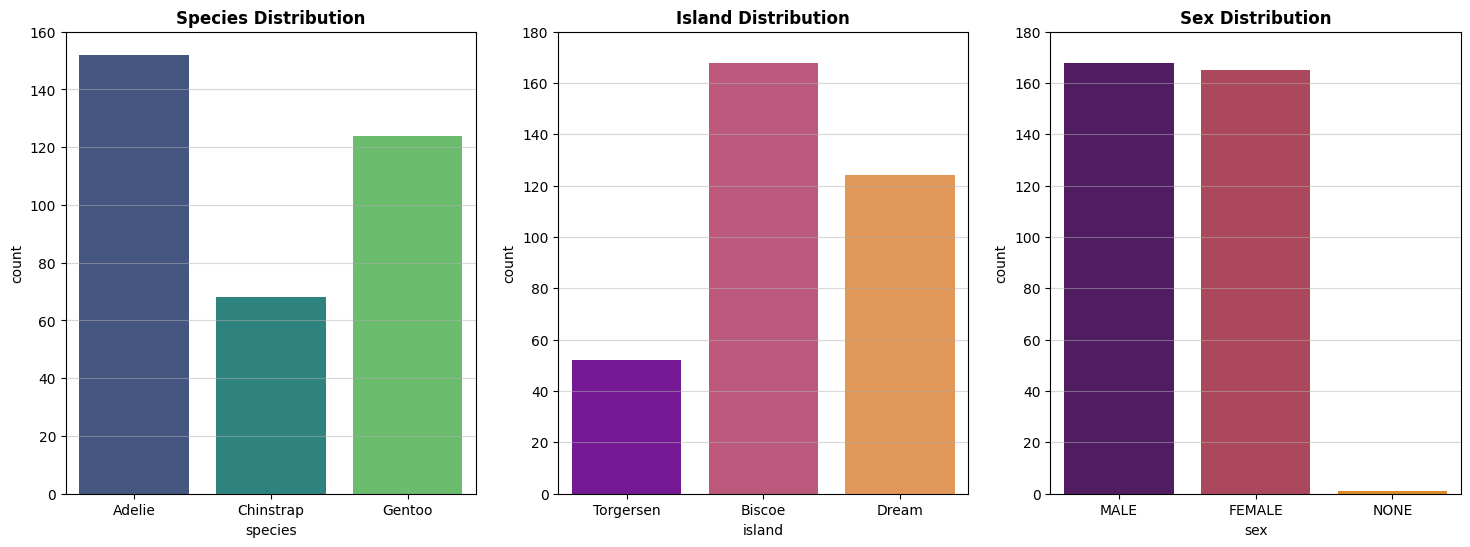

In [361]:
figure = plt.figure(figsize = (18, 6))

grid_spec = GridSpec(nrows = 1, ncols = 3, figure = figure)

first_axes = figure.add_subplot(grid_spec[0, 0])
sns.countplot(data = df, x = 'species', hue = 'species', legend = False, palette = 'viridis')
first_axes.set_ylim(0, 160)
first_axes.grid(axis = 'y', alpha = 0.5)
first_axes.set_title('Species Distribution', fontweight = 'bold')

second_axes = figure.add_subplot(grid_spec[0, 1])
sns.countplot(data = df, x = 'island', hue = 'island', legend = False, palette = 'plasma')
second_axes.set_ylim(0, 180)
second_axes.grid(axis = 'y', alpha = 0.5)
second_axes.set_title('Island Distribution', fontweight = 'bold')

third_axes = figure.add_subplot(grid_spec[0, 2])
sns.countplot(data = df, x = 'sex', hue = 'sex', legend = False, palette = 'inferno')
third_axes.xaxis.set_ticks([0, 1, 2])
third_axes.xaxis.set_ticklabels(['MALE', 'FEMALE', 'NONE'])
third_axes.set_ylim(0, 180)
third_axes.grid(axis = 'y', alpha = 0.5)
third_axes.set_title('Sex Distribution', fontweight = 'bold')

plt.show()

- The largest penguin species is the Adelie ~ 150.
- The most densely populated island is Biscoe ~ 165.
- The number of males and females is almost the same. There are a few gaps.

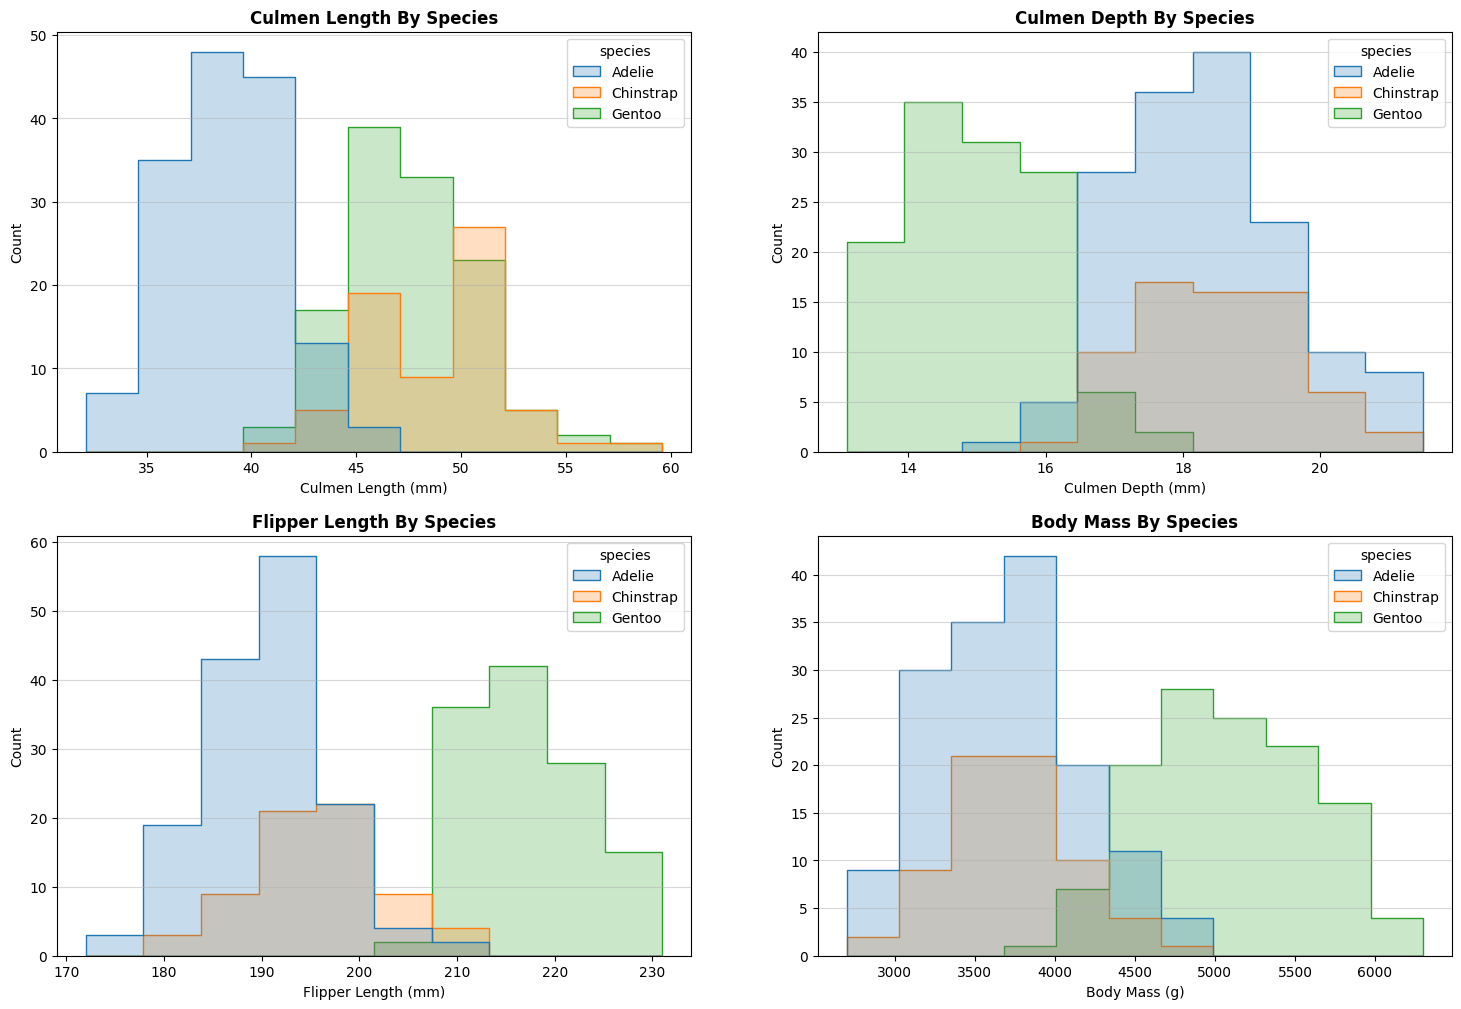

In [362]:
figure = plt.figure(figsize = (18, 12))

grid_spec = GridSpec(nrows = 2, ncols = 2, figure = figure)

first_axes = figure.add_subplot(grid_spec[0, 0])
sns.histplot(data = df, x = 'culmen_length_mm', hue = 'species', element = 'step')
first_axes.set_xlabel('Culmen Length (mm)')
first_axes.grid(axis = 'y', alpha = 0.5)
first_axes.set_title('Culmen Length By Species', fontweight = 'bold')

second_axes = figure.add_subplot(grid_spec[0, 1])
sns.histplot(data = df, x = 'culmen_depth_mm', hue = 'species', element = 'step')
second_axes.set_xlabel('Culmen Depth (mm)')
second_axes.grid(axis = 'y', alpha = 0.5)
second_axes.set_title('Culmen Depth By Species', fontweight = 'bold')

third_axes = figure.add_subplot(grid_spec[1, 0])
sns.histplot(data = df, x = 'flipper_length_mm', hue = 'species', element = 'step')
third_axes.set_xlabel('Flipper Length (mm)')
third_axes.grid(axis = 'y', alpha = 0.5)
third_axes.set_title('Flipper Length By Species', fontweight = 'bold')

fourth_axes = figure.add_subplot(grid_spec[1, 1])
sns.histplot(data = df, x = 'body_mass_g', hue = 'species', element = 'step')
fourth_axes.set_xlabel('Body Mass (g)')
fourth_axes.grid(axis = 'y', alpha = 0.5)
fourth_axes.set_title('Body Mass By Species', fontweight = 'bold')

plt.show()

- The Adelie species has the shortest beak. Chinstrap has the average, while Gentoo has the longest.
- The Gentoo has the smallest beak width, while the Adelie and Chinstrap have approximately the same beak width.
- Chinstrap and Adelie have approximately the same flipper length, while Gentoo has the longest flipper.
- Gentoo has the largest weight, while Adelie and Chinstrap have approximately equal weights.

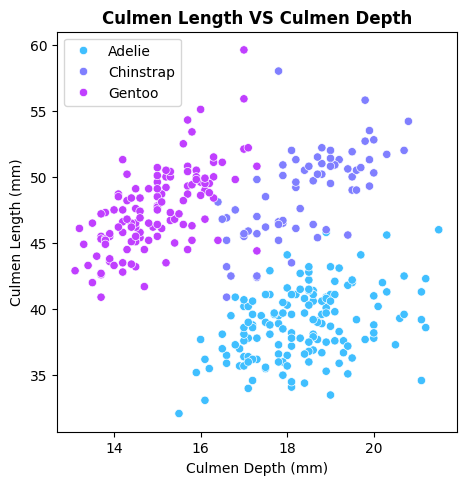

In [363]:
figure = plt.figure(figsize = (4, 4))

axes = figure.add_axes([0, 0, 1, 1])
sns.scatterplot(data = df, x = 'culmen_depth_mm', y = 'culmen_length_mm', hue = 'species', palette = 'cool')
axes.set_xlabel('Culmen Depth (mm)')
axes.set_ylabel('Culmen Length (mm)')
axes.set_title('Culmen Length VS Culmen Depth', fontweight = 'bold')
axes.legend()

plt.show()

- All the conclusions that were clear from the distributions are confirmed on this graph.

## 🫧 **3. Data cleaning and preparation**

In [364]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [365]:
df.shape

(344, 7)

In [366]:
df.dropna(axis = 0, how = 'any', inplace = True)

In [367]:
df.shape

(334, 7)

In [368]:
categorical_columns = df.select_dtypes(include = ['object']).drop('species', axis = 1).columns

In [369]:
df = pd.get_dummies(data = df, columns = categorical_columns, drop_first = True)

In [370]:
df.shape

(334, 9)

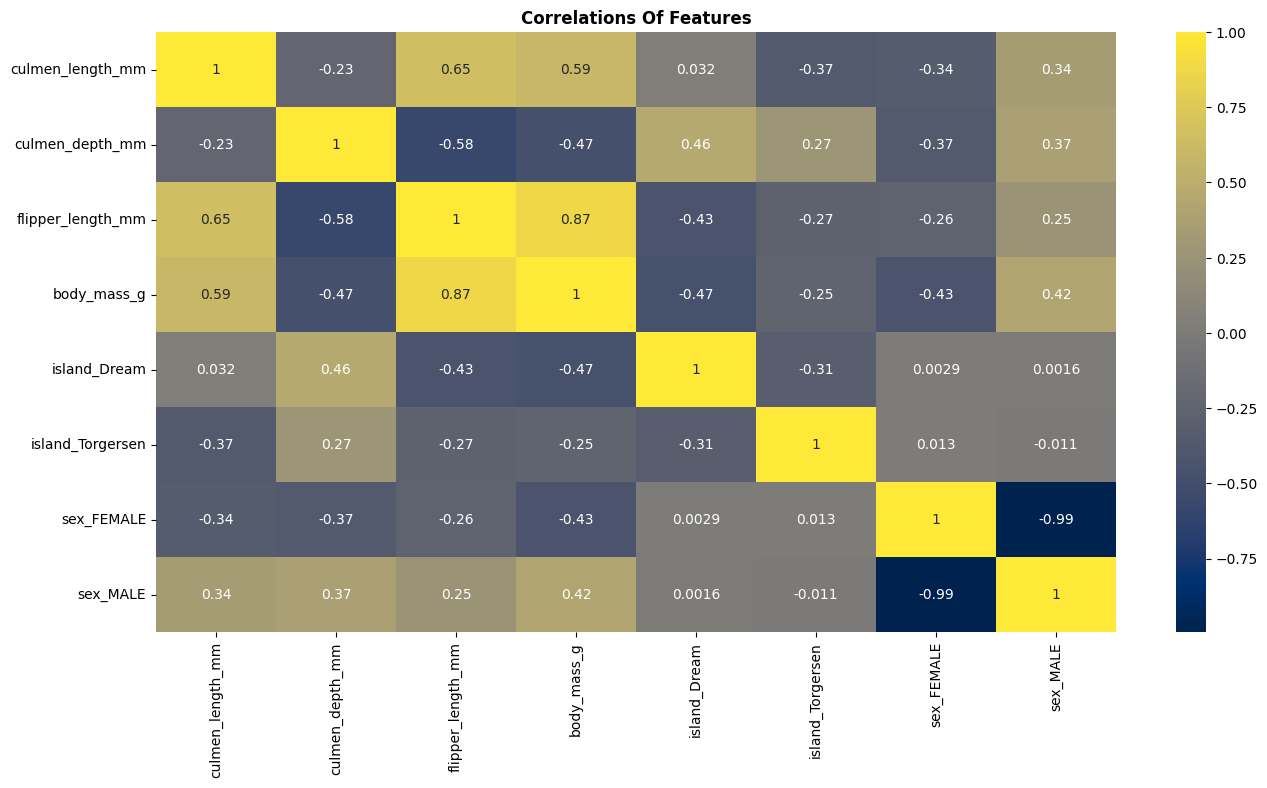

In [371]:
figure = plt.figure(figsize = (12, 6))

df_heat = df.drop('species', axis = 1).corr()

axes = figure.add_axes([0, 0, 1, 1])
sns.heatmap(df_heat, annot = True, cmap = 'cividis')
axes.set_title('Correlations Of Features', fontweight = 'bold')

plt.show()

- Body mass correlates very well with flipper length ~ 0.87
- It is clear that the gender of a male and a female is inversely correlated ~ -0.99

## ✂️ **4. Splitting the data**

In [372]:
X = df.drop('species', axis = 1)

In [373]:
y = df['species']

In [374]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True)

## 📐 **5. Feature Scaling**

In [375]:
scaler = StandardScaler()

In [376]:
X_train_numerical_columns = X_train.select_dtypes(include = ['number']).columns

In [377]:
X_train[X_train_numerical_columns] = scaler.fit_transform(X_train[X_train_numerical_columns])

In [378]:
X_test_numerical_columns = X_test.select_dtypes(include = ['number']).columns

In [379]:
X_test[X_test_numerical_columns] = scaler.fit_transform(X_test[X_test_numerical_columns])

## 🚀 **6. Run SVM**

In [380]:
model = SVC()
model.fit(X_train, y_train)

prediction = model.predict(X_test)

## 🔢 **7. Confusion Matrix**

In [381]:
species = y.unique()

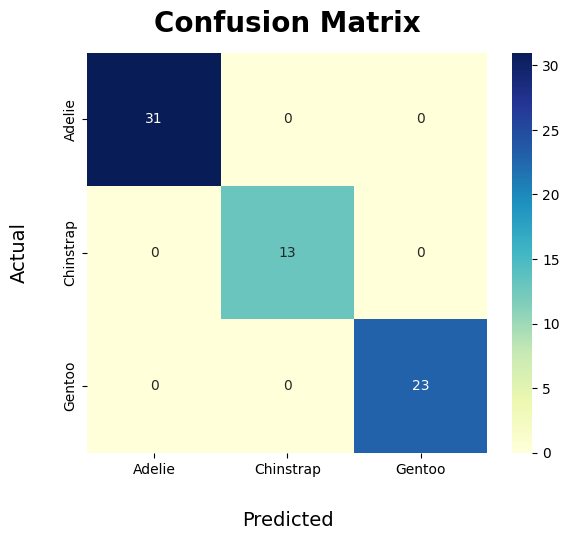

In [382]:
figure = plt.figure(figsize = (5, 4))

matrix_heat = confusion_matrix(y_test, prediction)

axes = figure.add_axes([0, 0, 1, 1])
sns.heatmap(matrix_heat, annot = True, cmap = 'YlGnBu')
axes.xaxis.set_ticklabels(species)
axes.yaxis.set_ticklabels(species)
axes.set_xlabel('Predicted', labelpad = 25, fontsize = 14)
axes.set_ylabel('Actual', labelpad = 25, fontsize = 14)
axes.set_title('Confusion Matrix', fontweight = 'bold', pad = 15, fontsize = 20)

plt.show()

## 📢 **8. Classification Report**

In [383]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

